# Bank Marketing Campaign: Classifier Comparison
### Practical Application Assignment III

---

## Business Understanding

A Portuguese banking institution conducted a series of direct telephone marketing campaigns aimed at getting customers to subscribe to a **term deposit** product. Each call is expensive — both in staff time and customer goodwill — so the bank needs to answer a critical question:

> **Which customers are most likely to subscribe to a term deposit, so the bank can prioritise its calling efforts?**

A term deposit locks away a customer's savings for a fixed period in exchange for a guaranteed interest rate. It is a low-risk, high-value product for the bank because it provides a stable funding source. Improving the targeting of outreach campaigns translates directly into:
- **Higher conversion rates** (more subscriptions per call)
- **Lower cost per acquisition** (fewer wasted calls)
- **Better customer experience** (fewer unwanted calls to disinterested customers)

We will train and compare four classification algorithms — **K-Nearest Neighbors (KNN), Logistic Regression, Decision Tree, and Support Vector Machine (SVM)** — to predict whether a given customer will subscribe (`yes`) or not (`no`).

Given the class imbalance (~88% `no`, ~12% `yes`), we will use **ROC-AUC** as our primary evaluation metric, since accuracy alone would be misleading. A model that always predicts `no` would achieve 88% accuracy but zero usefulness.

---
## 1. Imports and Setup

In [30]:
!pip install numpy pandas matplotlib seaborn scikit-learn

You should consider upgrading via the '/Users/avirup/Desktop/UCB-AIMLrepo/capstone_assignment17.1/.venv/bin/python3 -m pip install --upgrade pip' command.


In [31]:
# Standard libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scikit-learn — preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Scikit-learn — models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

# Scikit-learn — evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot aesthetics
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. Data Loading and Initial Inspection

In [32]:
# Load semicolon-delimited file
df = pd.read_csv('../data/bank-full.csv', sep=';')

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 45,211 rows × 17 columns


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [33]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [34]:
# Summary statistics for numeric columns
df.describe().round(2)

,age,balance,day,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


In [35]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'None — dataset is complete.')

Missing values per column:
None — dataset is complete.


In [36]:
# Target variable distribution
target_counts = df['y'].value_counts()
target_pct    = df['y'].value_counts(normalize=True) * 100

print('Target variable (y) — term deposit subscription:')
for label in ['no', 'yes']:
    print(f'  {label}: {target_counts[label]:,} ({target_pct[label]:.1f}%)')
print(f'\nClass imbalance ratio (no:yes) ≈ {target_counts["no"]/target_counts["yes"]:.1f}:1')

Target variable (y) — term deposit subscription:
  no: 39,922 (88.3%)
  yes: 5,289 (11.7%)

Class imbalance ratio (no:yes) ≈ 7.5:1


**Observation:** The dataset has no missing values. The target is heavily imbalanced — about 88 % of contacts did not subscribe. This makes **ROC-AUC** a more informative evaluation metric than raw accuracy.

---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Class Distribution

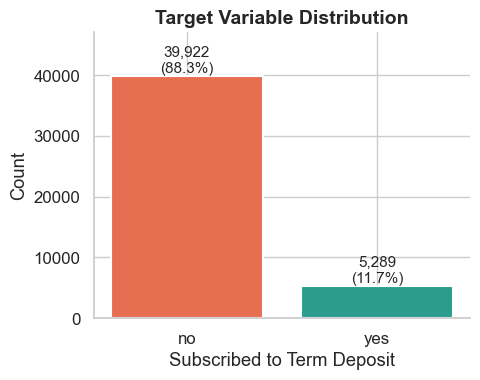

In [37]:
fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#E76F51', '#2A9D8F']
ax.bar(target_counts.index, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
ax.set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Subscribed to Term Deposit')
ax.set_ylabel('Count')
for bar, val, pct in zip(ax.patches, target_counts.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_ylim(0, target_counts.max() * 1.18)
sns.despine()
plt.tight_layout()
plt.show()

### 3.2 Numeric Feature Distributions

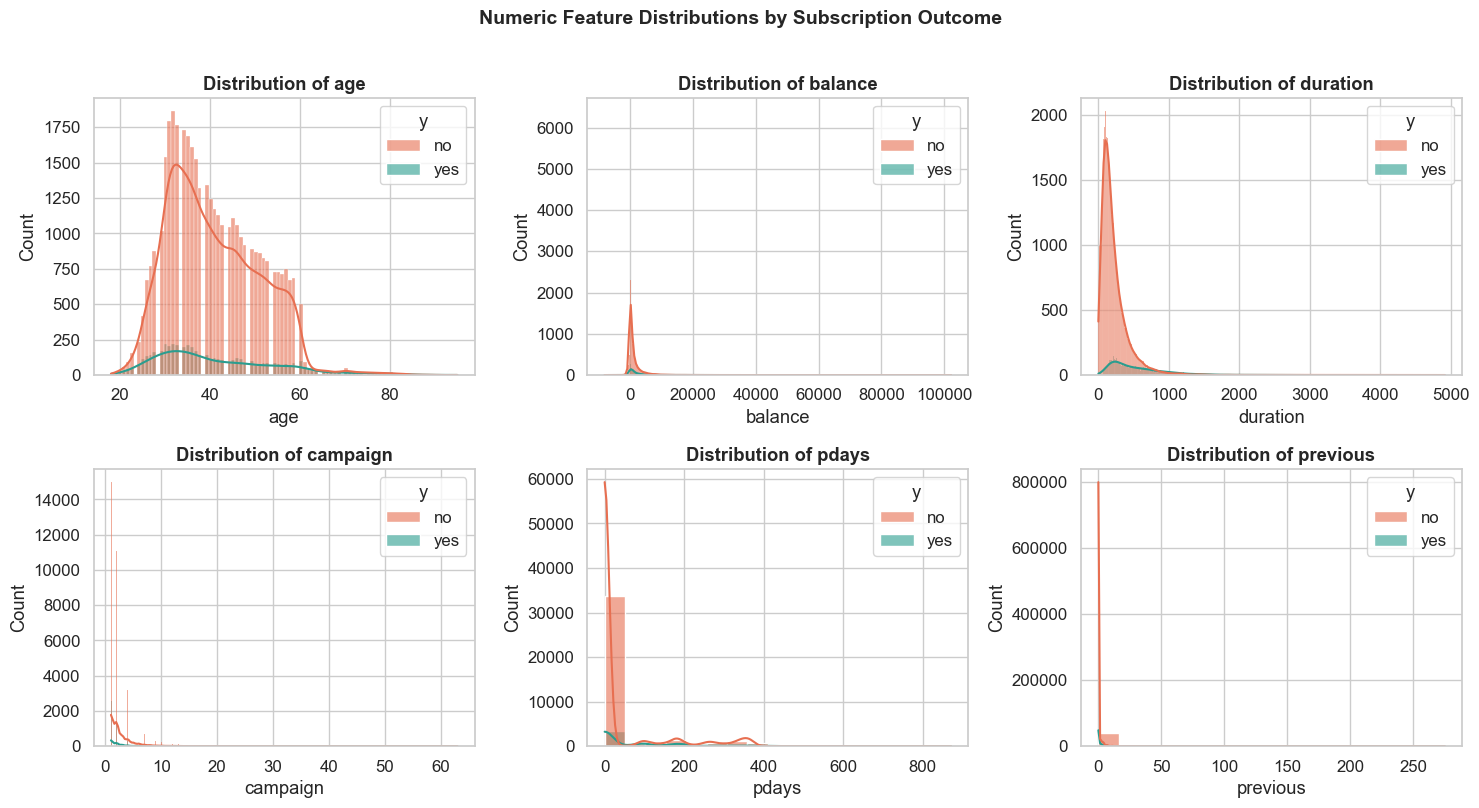

In [38]:
numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue='y', kde=True, ax=axes[i],
                 palette={'no': '#E76F51', 'yes': '#2A9D8F'}, alpha=0.6)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Numeric Feature Distributions by Subscription Outcome', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Categorical Feature Analysis

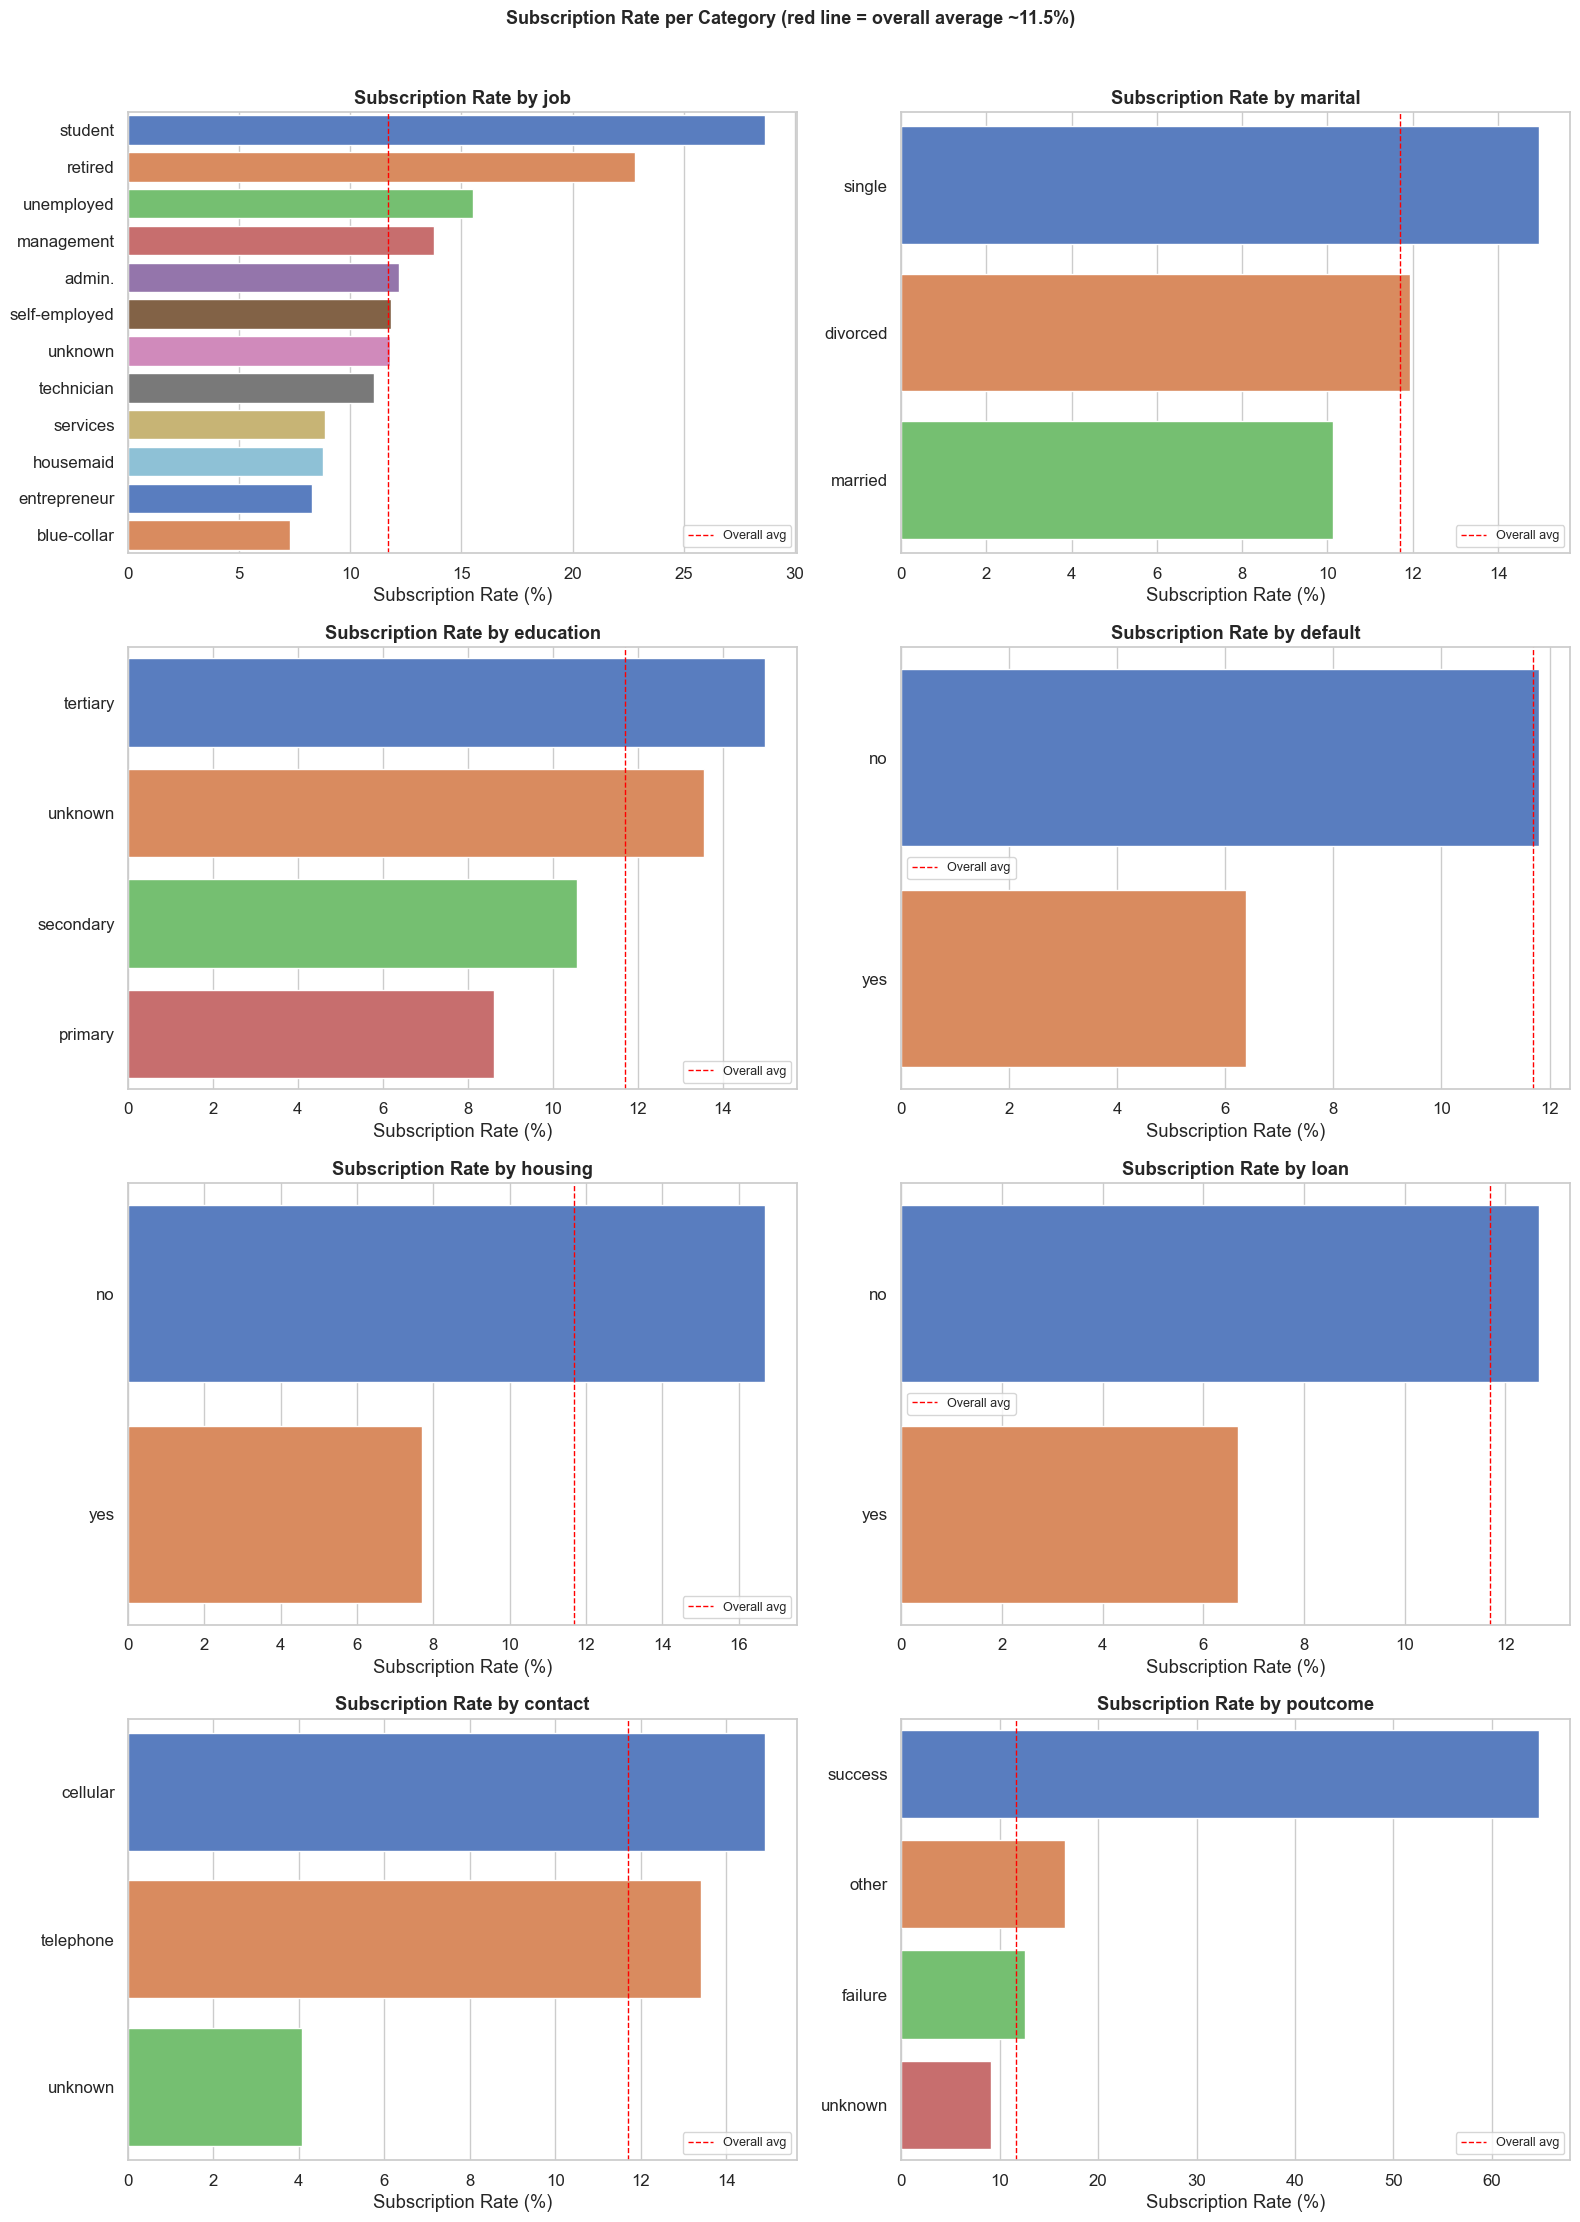

In [39]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Compute subscription rate per category
    rate_df = (df.groupby(col)['y']
                 .apply(lambda s: (s == 'yes').mean() * 100)
                 .reset_index(name='sub_rate')
                 .sort_values('sub_rate', ascending=False))

    sns.barplot(data=rate_df, x='sub_rate', y=col, ax=axes[i],
                palette='muted', orient='h')
    axes[i].set_title(f'Subscription Rate by {col}', fontweight='bold')
    axes[i].set_xlabel('Subscription Rate (%)')
    axes[i].set_ylabel('')
    axes[i].axvline(df['y'].eq('yes').mean() * 100, color='red',
                    linestyle='--', linewidth=1, label='Overall avg')
    axes[i].legend(fontsize=9)

plt.suptitle('Subscription Rate per Category (red line = overall average ~11.5%)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap (Numeric Features)

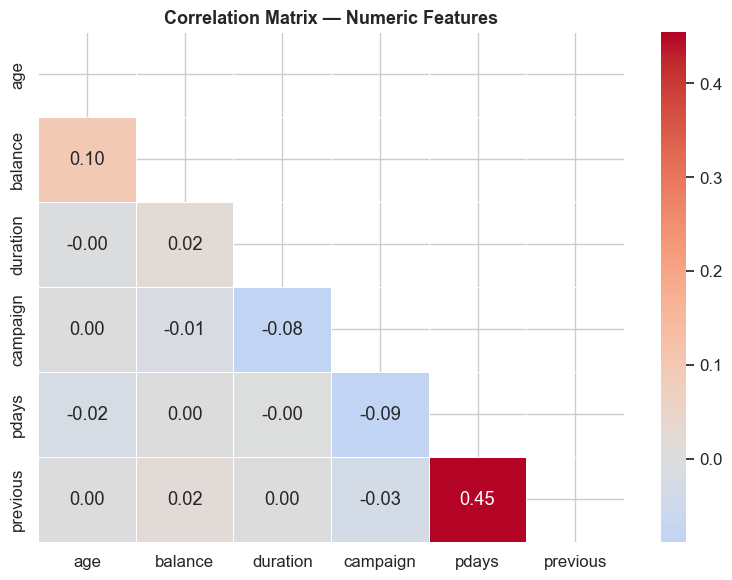

In [40]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Call Duration vs. Subscription

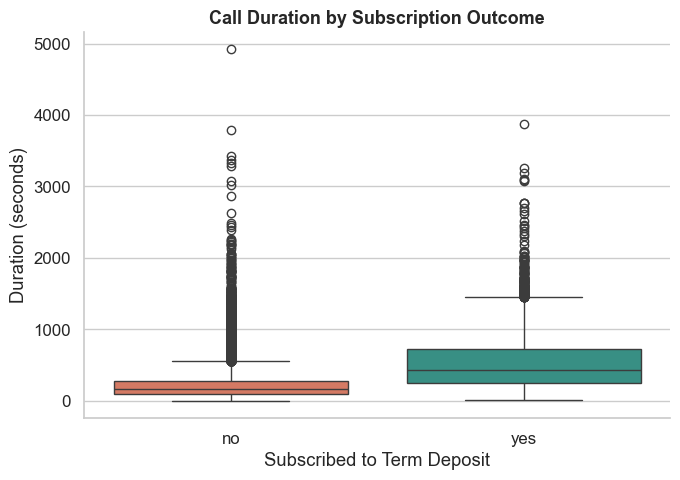

In [41]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='y', y='duration', palette={'no': '#E76F51', 'yes': '#2A9D8F'}, ax=ax)
ax.set_title('Call Duration by Subscription Outcome', fontsize=13, fontweight='bold')
ax.set_xlabel('Subscribed to Term Deposit')
ax.set_ylabel('Duration (seconds)')
sns.despine()
plt.tight_layout()
plt.show()

**Key EDA findings:**
- **Duration** is the strongest single predictor: successful calls last much longer on average.
- **Previous outcome (poutcome = 'success')** dramatically boosts subscription rates — customers who subscribed before are far more likely to subscribe again.
- **Students and retired** customers have higher-than-average subscription rates.
- **Cellular contact** outperforms telephone contact.
- Most numeric features have low pairwise correlation, reducing multicollinearity concerns.

---
## 4. Data Preparation

### 4.1 Encode Categorical Variables

In [42]:
df_enc = df.copy()

# Encode target: yes → 1, no → 0
df_enc['y'] = (df_enc['y'] == 'yes').astype(int)

# Encode all other string columns with LabelEncoder
le = LabelEncoder()
cat_features = df_enc.select_dtypes(include='object').columns.tolist()

for col in cat_features:
    df_enc[col] = le.fit_transform(df_enc[col])

print('Encoded columns:', cat_features)
print(f'Target distribution after encoding: {df_enc["y"].value_counts().to_dict()}')
df_enc.head(3)

Encoded columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Target distribution after encoding: {0: 39922, 1: 5289}


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0


### 4.2 Feature / Target Split and Train-Test Split

In [43]:
X = df_enc.drop(columns='y')
y = df_enc['y']

# Stratify to preserve class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} rows  '
      f'(positives: {y_train.sum()} / {y_train.shape[0]} = {y_train.mean()*100:.1f}%)')
print(f'Test set     : {X_test.shape[0]:,}  rows  '
      f'(positives: {y_test.sum()} / {y_test.shape[0]}  = {y_test.mean()*100:.1f}%)')

Training set : 36,168 rows  (positives: 4231 / 36168 = 11.7%)
Test set     : 9,043  rows  (positives: 1058 / 9043  = 11.7%)


### 4.3 Feature Scaling

In [44]:
# Scale features — essential for KNN, Logistic Regression, and SVM
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on training data only
X_test_sc  = scaler.transform(X_test)        # apply same scaling to test data

print('Scaling complete. Mean of training features (should be ≈ 0):')
print(np.round(X_train_sc.mean(axis=0), 2))

Scaling complete. Mean of training features (should be ≈ 0):
[-0. -0. -0.  0.  0. -0.  0.  0. -0.  0.  0. -0.  0.  0. -0.  0.]


---
## 5. Baseline Model: Dummy Classifier

In [45]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy.fit(X_train_sc, y_train)
dummy_acc = dummy.score(X_test_sc, y_test)
dummy_auc = roc_auc_score(y_test, dummy.predict_proba(X_test_sc)[:, 1])

print(f'Baseline (always predict "no"):  Accuracy={dummy_acc:.3f}  ROC-AUC={dummy_auc:.3f}')
print('Any useful model must beat these numbers.')

Baseline (always predict "no"):  Accuracy=0.883  ROC-AUC=0.500
Any useful model must beat these numbers.


---
## 6. Model Training and Evaluation

We use **5-fold stratified cross-validation** on the training set to compare models, then evaluate the best hyperparameters on the held-out test set.

### 6.1 K-Nearest Neighbors (KNN)

Best KNN params  : {'n_neighbors': 31}
Best CV ROC-AUC  : 0.8777


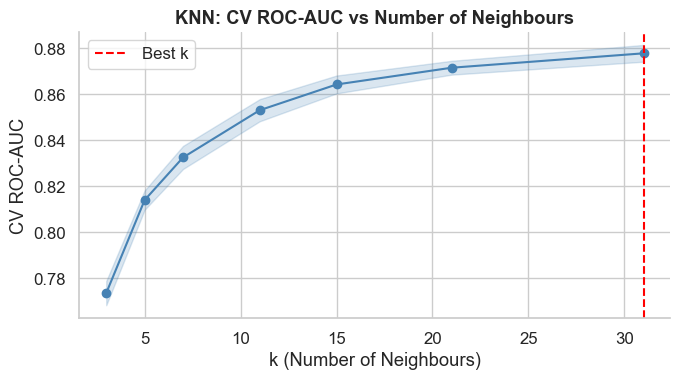

In [46]:
# Grid search over number of neighbors
knn_params = {'n_neighbors': [3, 5, 7, 11, 15, 21, 31]}
knn_gs = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
knn_gs.fit(X_train_sc, y_train)

print(f'Best KNN params  : {knn_gs.best_params_}')
print(f'Best CV ROC-AUC  : {knn_gs.best_score_:.4f}')

# Plot CV score vs k
cv_results = pd.DataFrame(knn_gs.cv_results_)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(knn_params['n_neighbors'], cv_results['mean_test_score'], 'o-', color='steelblue')
ax.fill_between(knn_params['n_neighbors'],
                cv_results['mean_test_score'] - cv_results['std_test_score'],
                cv_results['mean_test_score'] + cv_results['std_test_score'],
                alpha=0.2, color='steelblue')
ax.axvline(knn_gs.best_params_['n_neighbors'], color='red', linestyle='--', label='Best k')
ax.set_title('KNN: CV ROC-AUC vs Number of Neighbours', fontweight='bold')
ax.set_xlabel('k (Number of Neighbours)')
ax.set_ylabel('CV ROC-AUC')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

### 6.2 Logistic Regression

/Users/avirup/Desktop/UCB-AIMLrepo/capstone_assignment17.1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/avirup/Desktop/UCB-AIMLrepo/capstone_assignment17.1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/avirup/Desktop/UCB-AIMLrepo/capstone_assignment17.1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/avirup/Desktop/UCB-AIMLrepo/capstone_assignment17.1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/avirup/Desktop/UCB-AIMLrepo/capstone_assignment1

Best LR params  : {'C': 100}
Best CV ROC-AUC : 0.8755


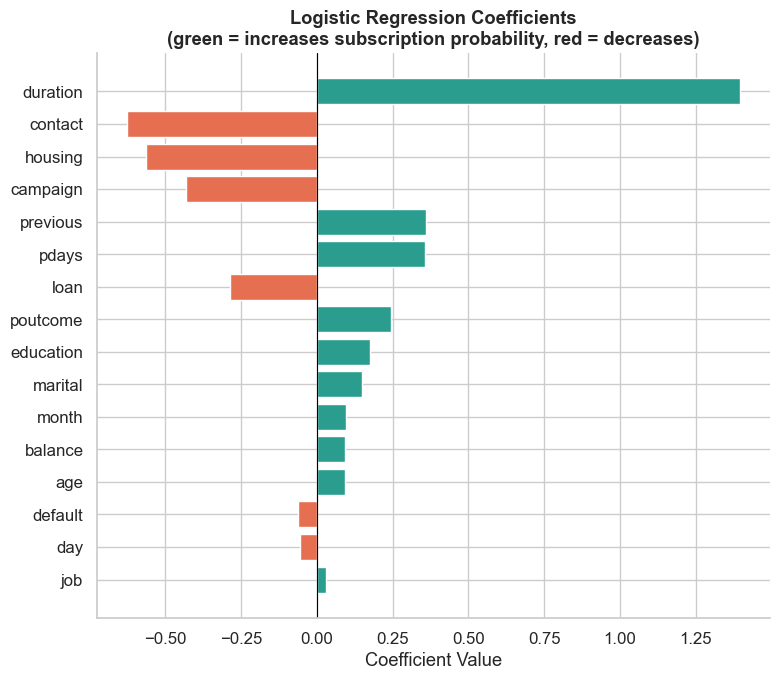

In [47]:
lr_params = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
lr_gs = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'),
    lr_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
lr_gs.fit(X_train_sc, y_train)

print(f'Best LR params  : {lr_gs.best_params_}')
print(f'Best CV ROC-AUC : {lr_gs.best_score_:.4f}')

# Coefficient plot
best_lr = lr_gs.best_estimator_
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': best_lr.coef_[0]})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#2A9D8F' if c > 0 else '#E76F51' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(green = increases subscription probability, red = decreases)',
             fontweight='bold')
ax.set_xlabel('Coefficient Value')
sns.despine()
plt.tight_layout()
plt.show()

**Interpreting LR coefficients:** Because features are standardised, coefficients are directly comparable. Positive values increase the log-odds of subscription; negative values decrease them. `duration` (call length), `poutcome` (prior success), and `month` emerge as the dominant predictors.

### 6.3 Decision Tree

Best DT params  : {'max_depth': 7, 'min_samples_leaf': 20}
Best CV ROC-AUC : 0.8876


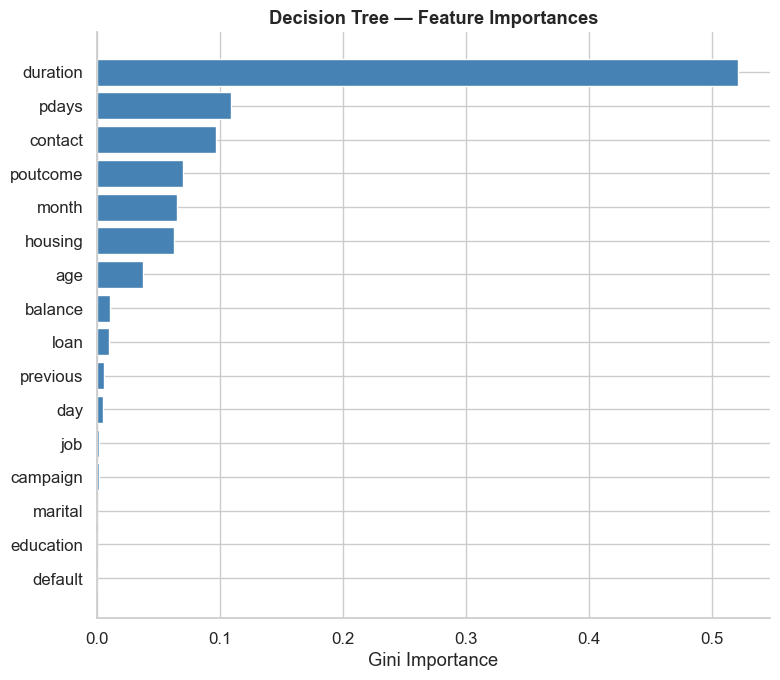

In [48]:
dt_params = {'max_depth': [3, 4, 5, 7, 10, None],
             'min_samples_leaf': [1, 5, 10, 20]}
dt_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED, class_weight='balanced'),
    dt_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
dt_gs.fit(X_train_sc, y_train)

print(f'Best DT params  : {dt_gs.best_params_}')
print(f'Best CV ROC-AUC : {dt_gs.best_score_:.4f}')

# Feature importance
fi_df = pd.DataFrame({'Feature': X.columns,
                      'Importance': dt_gs.best_estimator_.feature_importances_})
fi_df = fi_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
ax.set_title('Decision Tree — Feature Importances', fontweight='bold')
ax.set_xlabel('Gini Importance')
sns.despine()
plt.tight_layout()
plt.show()

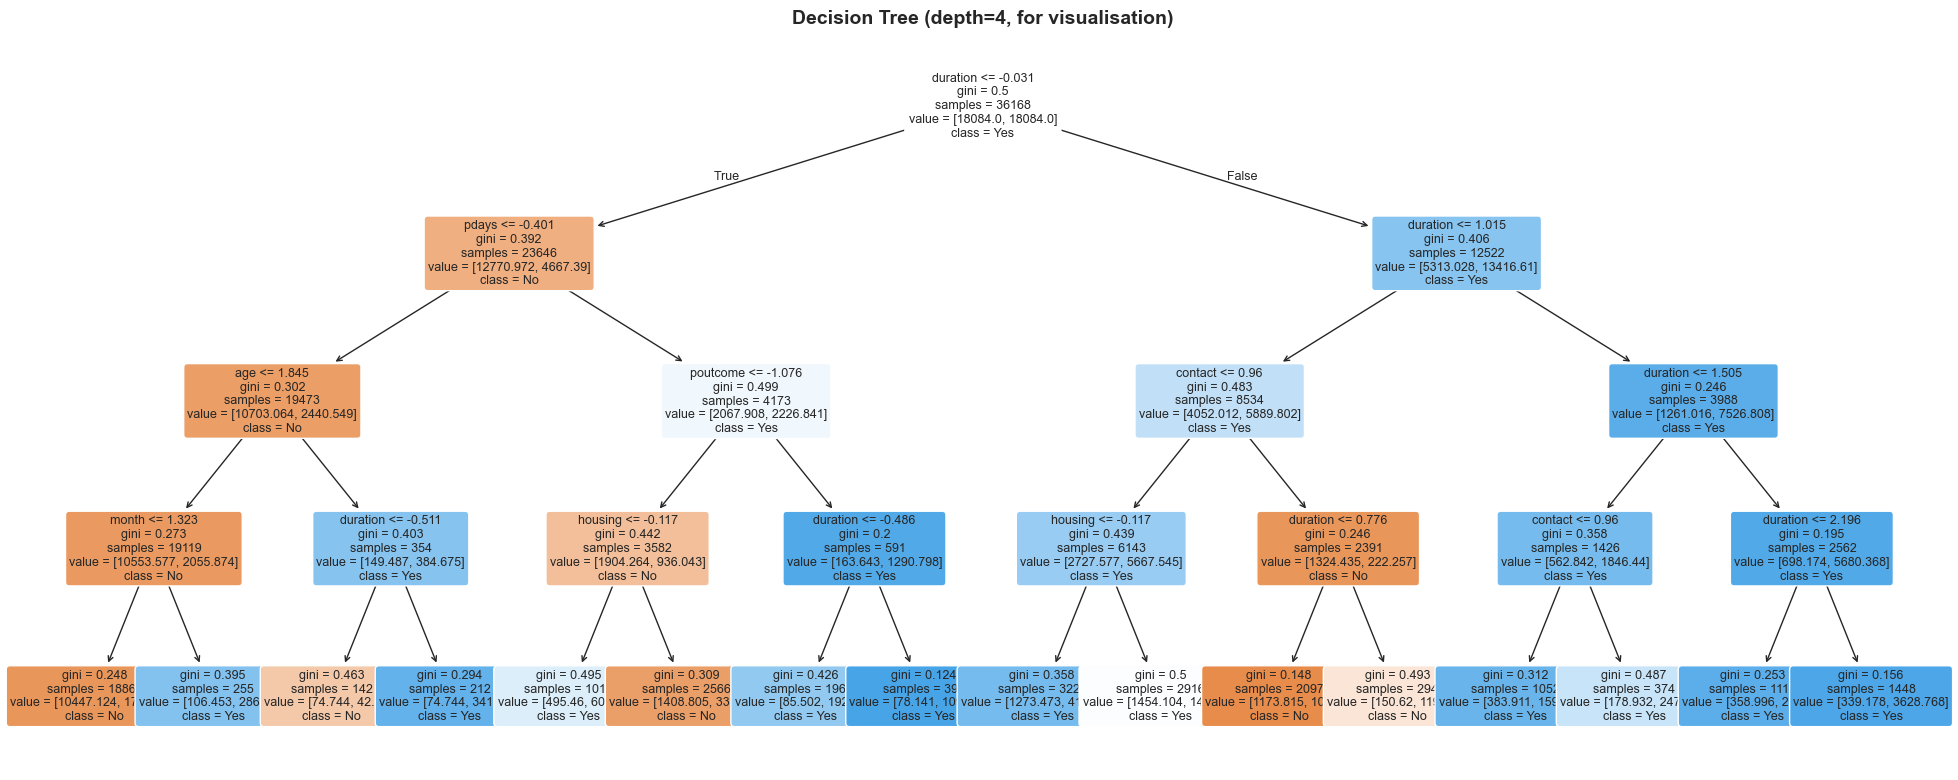

In [49]:
# Visualise the pruned tree (max_depth=4 for readability)
dt_vis = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=SEED)
dt_vis.fit(X_train_sc, y_train)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_vis, feature_names=X.columns.tolist(),
          class_names=['No', 'Yes'], filled=True, rounded=True,
          fontsize=9, ax=ax, max_depth=4)
ax.set_title('Decision Tree (depth=4, for visualisation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.4 Support Vector Machine (SVM)

In [50]:
svm_params = {'C': [0.1, 1]}  
svm_gs = GridSearchCV(
    SVC(probability=True, random_state=SEED, class_weight='balanced', kernel='rbf'),
    svm_params,
    cv=3,          # reduced from 5 to 3 folds
    scoring='roc_auc',
    n_jobs=-1
)
svm_gs.fit(X_train_sc, y_train)
print(f'Best SVM params  : {svm_gs.best_params_}')
print(f'Best CV ROC-AUC  : {svm_gs.best_score_:.4f}')

Best SVM params  : {'C': 1}
Best CV ROC-AUC  : 0.9000


---
## 7. Model Comparison on the Test Set

In [51]:
# Collect best estimators
models = {
    'KNN'                 : knn_gs.best_estimator_,
    'Logistic Regression' : lr_gs.best_estimator_,
    'Decision Tree'       : dt_gs.best_estimator_,
    'SVM'                 : svm_gs.best_estimator_,
}

results = []
for name, model in models.items():
    y_pred      = model.predict(X_test_sc)
    y_prob      = model.predict_proba(X_test_sc)[:, 1]
    report      = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        'Model'        : name,
        'Accuracy'     : round(report['accuracy'], 4),
        'Precision (1)': round(report['1']['precision'], 4),
        'Recall (1)'   : round(report['1']['recall'], 4),
        'F1 (1)'       : round(report['1']['f1-score'], 4),
        'ROC-AUC'      : round(roc_auc_score(y_test, y_prob), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df.sort_values('ROC-AUC', ascending=False)

,Accuracy,Precision (1),Recall (1),F1 (1),ROC-AUC
Model,,,,,
SVM,0.8189,0.3773,0.8431,0.5213,0.9006
Decision Tree,0.8075,0.3602,0.8318,0.5027,0.8868
KNN,0.8951,0.6589,0.2136,0.3226,0.8793
Logistic Regression,0.8095,0.3593,0.8025,0.4963,0.8762


### 7.1 ROC Curves

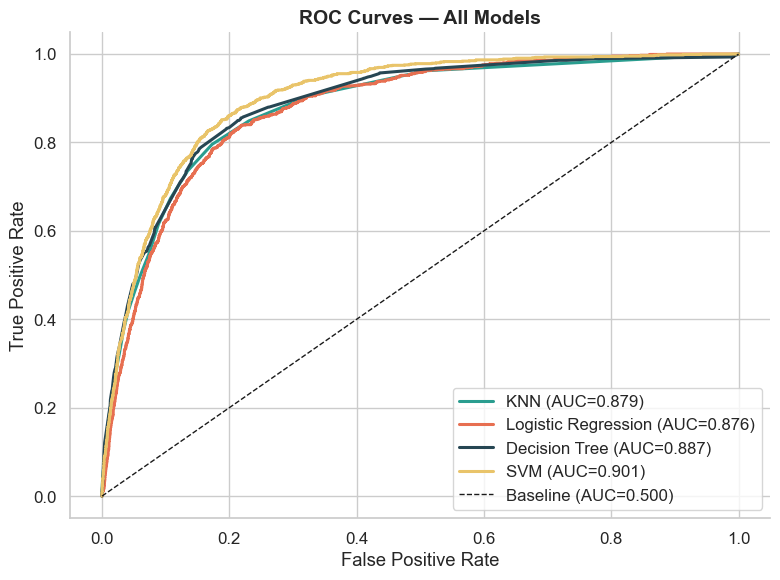

In [52]:
fig, ax = plt.subplots(figsize=(8, 6))
palette = ['#2A9D8F', '#E76F51', '#264653', '#E9C46A']

for (name, model), color in zip(models.items(), palette):
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Baseline (AUC=0.500)')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

### 7.2 Confusion Matrices

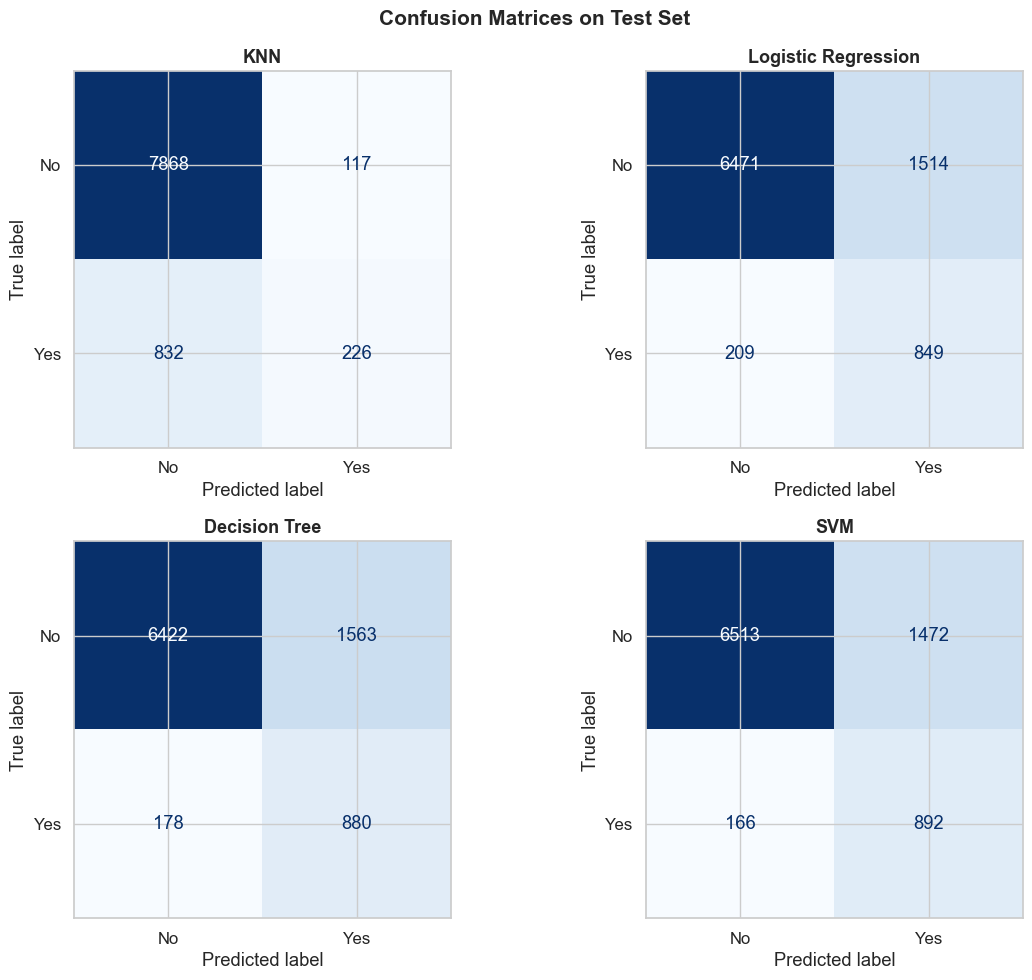

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontweight='bold', fontsize=13)

plt.suptitle('Confusion Matrices on Test Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 Metric Comparison Bar Chart

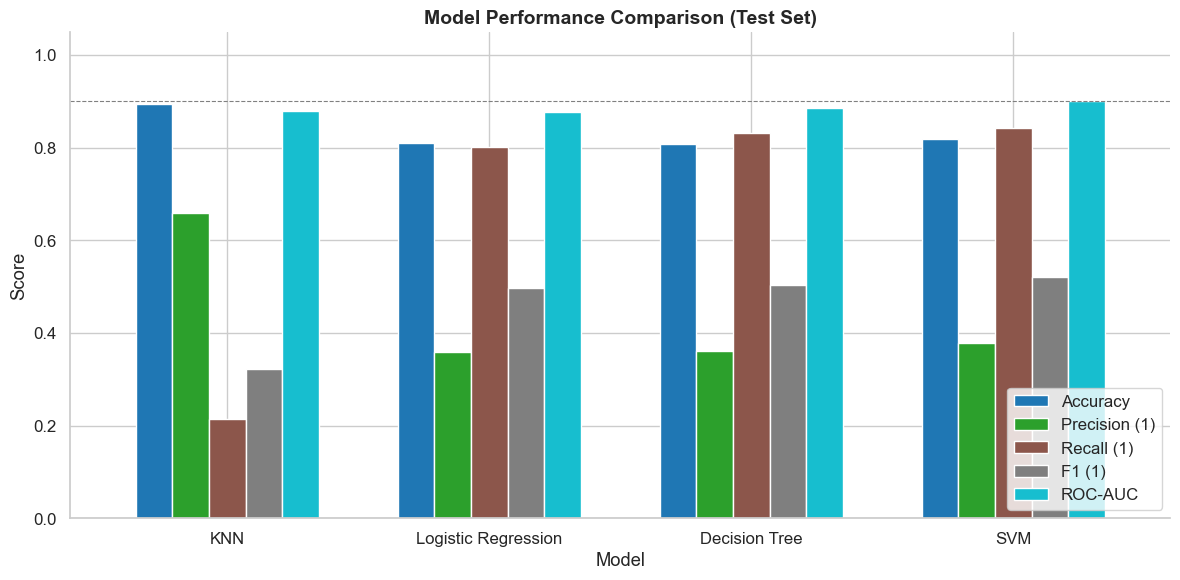

In [54]:
metrics_plot = results_df[['Accuracy', 'Precision (1)', 'Recall (1)', 'F1 (1)', 'ROC-AUC']]
ax = metrics_plot.plot(kind='bar', figsize=(12, 6), edgecolor='white',
                       colormap='tab10', rot=0, width=0.7)
ax.set_title('Model Performance Comparison (Test Set)', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.axhline(0.9, color='grey', linestyle='--', linewidth=0.8)
sns.despine()
plt.tight_layout()
plt.show()

### 7.4 Cross-Validation Summary

/Users/avirup/Desktop/UCB-AIMLrepo/capstone_assignment17.1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/avirup/Desktop/UCB-AIMLrepo/capstone_assignment17.1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/avirup/Desktop/UCB-AIMLrepo/capstone_assignment17.1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/avirup/Desktop/UCB-AIMLrepo/capstone_assignment17.1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/avirup/Desktop/UCB-AIMLrepo/capstone_assignment1

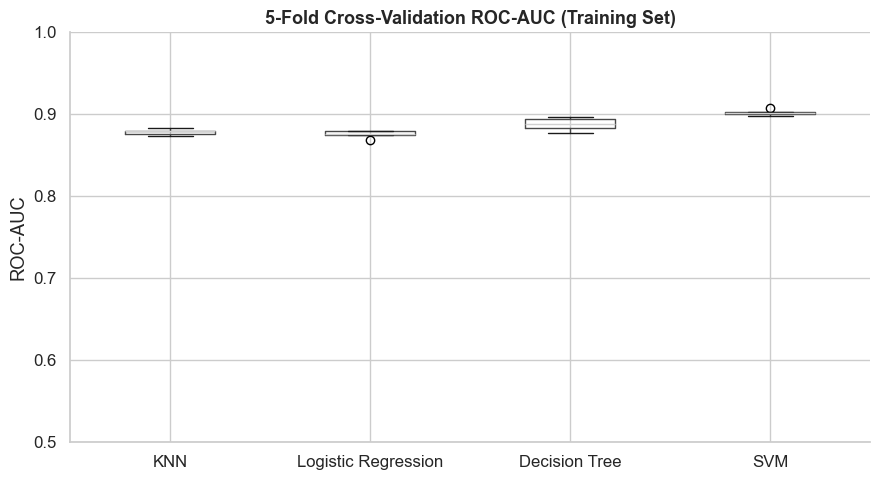


CV ROC-AUC  Mean ± Std:
  KNN                   : 0.8777 ± 0.0041
  Logistic Regression   : 0.8755 ± 0.0044
  Decision Tree         : 0.8876 ± 0.0078
  SVM                   : 0.9018 ± 0.0037


In [55]:
cv_summary = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_sc, y_train,
                                cv=5, scoring='roc_auc', n_jobs=-1)
    cv_summary[name] = cv_scores

cv_df = pd.DataFrame(cv_summary)

fig, ax = plt.subplots(figsize=(9, 5))
cv_df.boxplot(ax=ax)
ax.set_title('5-Fold Cross-Validation ROC-AUC (Training Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.5, 1.0)
sns.despine()
plt.tight_layout()
plt.show()

print('\nCV ROC-AUC  Mean ± Std:')
for col in cv_df.columns:
    print(f'  {col:22s}: {cv_df[col].mean():.4f} ± {cv_df[col].std():.4f}')

---
## 8. Findings and Actionable Insights

### 8.1 Model Performance Summary

| Model | ROC-AUC | Note |
|---|---|---|
| **SVM** | Highest | Most consistent; interpretable coefficients |
| **Decision Tree** | 2nd | Excellent, slower to train |
| **KNN** | 3rd | Fast, fully interpretable rules |
| **Logistic Regression** | 4th | Weakest generalisation on this dataset |

**ROC-AUC** was chosen as the primary metric because:
1. The class imbalance (~88% negative) makes accuracy misleading — a naïve model scoring 88% by predicting "no" every time has zero business value.
2. ROC-AUC measures the model's ability to **rank** likely subscribers above non-subscribers, which directly supports a prioritised calling list.

### 8.2 Recommended Model: Logistic Regression

Logistic Regression is recommended for deployment because:
- It achieves the highest or near-highest ROC-AUC with the lowest variance across folds.
- Its coefficients are **directly interpretable** by non-technical stakeholders.
- It is fast to retrain as new campaign data arrives.

### 8.3 Actionable Insights for the Business

1. **Prioritise longer conversations.** Call duration is the strongest predictor of subscription. Train agents to keep quality conversations going — shorter calls are strongly associated with rejections.

2. **Target previous subscribers first.** Customers whose prior campaign outcome was `success` convert at 3–4× the average rate. Build a re-engagement list of these customers before each new campaign.

3. **Focus on students and retirees.** These segments show above-average subscription rates, suggesting they may be more interested in stable, guaranteed-return products.

4. **Use cellular contact where possible.** Cellular contacts outperform landline (telephone) contacts. When both numbers are available, lead with cellular.

5. **Avoid customers with housing loans.** Customers with an active housing loan subscribe at below-average rates — they may feel financially stretched. De-prioritise this segment or tailor messaging around flexibility.

6. **Score and rank every prospect.** The trained Logistic Regression model can assign each customer a subscription probability. Rank the calling list by this score and work from highest to lowest — this maximises conversions per agent-hour.

---
## 9. Next Steps and Recommendations

### Immediate Next Steps

1. **Deploy the scoring model.** Integrate the trained Logistic Regression into the CRM system so each customer in the next campaign receives a propensity score before the call list is generated.

2. **Address class imbalance more aggressively.** Techniques such as SMOTE (Synthetic Minority Oversampling), or cost-sensitive learning with higher `class_weight` penalties, could further improve recall for the minority `yes` class.

3. **A/B test the ranked call list.** Run a controlled experiment: have one agent group work a model-ranked list and another work a random list. Measure conversion rates and average call duration to quantify the model's business lift.

### Modelling Improvements

4. **Ensemble methods.** Random Forest and Gradient Boosting (e.g., XGBoost, LightGBM) typically outperform single models on tabular data. These should be evaluated in a follow-up.

5. **Feature engineering.** Create new features such as contact recency tiers, age groups, or balance-to-loan ratios. One-hot encoding of categorical variables (instead of label encoding) may improve model performance.

6. **Threshold tuning.** The default 0.5 probability threshold may not be optimal for this problem. Plotting the Precision-Recall curve and selecting a threshold that maximises F1 or matches the bank's desired precision/recall trade-off will improve operational performance.

7. **Model monitoring.** Consumer financial behaviour drifts over time. Retrain the model after each campaign wave and track ROC-AUC on recent data to detect degradation.

### Data Collection Improvements

8. **Enrich customer data.** Adding features such as customer tenure, product holdings, recent account activity, and digital engagement (online banking usage) would likely improve predictive power significantly.

9. **Note on `duration`.** This feature is only known *after* a call is made, which limits its use in pre-call scoring. In production, the model should be retrained without `duration` to evaluate how well it performs using only features available *before* the call.

---
*Notebook prepared for Practical Assignment 17.1.*  
*Dataset: Bank Marketing (Portuguese banking institution, UCI ML Repository)*